# Project Title and Problem Statement
## Project Title

***Clinical Biomarker Data Analysis and Preprocessing Using Python***

## Problem Statement

Analyze clinical and blood-related biomarker measurements using Python to understand their distributions, identify and investigate outliers, handle unusual data appropriately, and apply normalization and standardization techniques as preparation for machine learning.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving dataR2.csv to dataR2 (2).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("dataR2.csv")

df.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [3]:
df.describe()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,1.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,1.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,1.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,2.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,2.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,2.000000


In [4]:
df.shape

(116, 10)

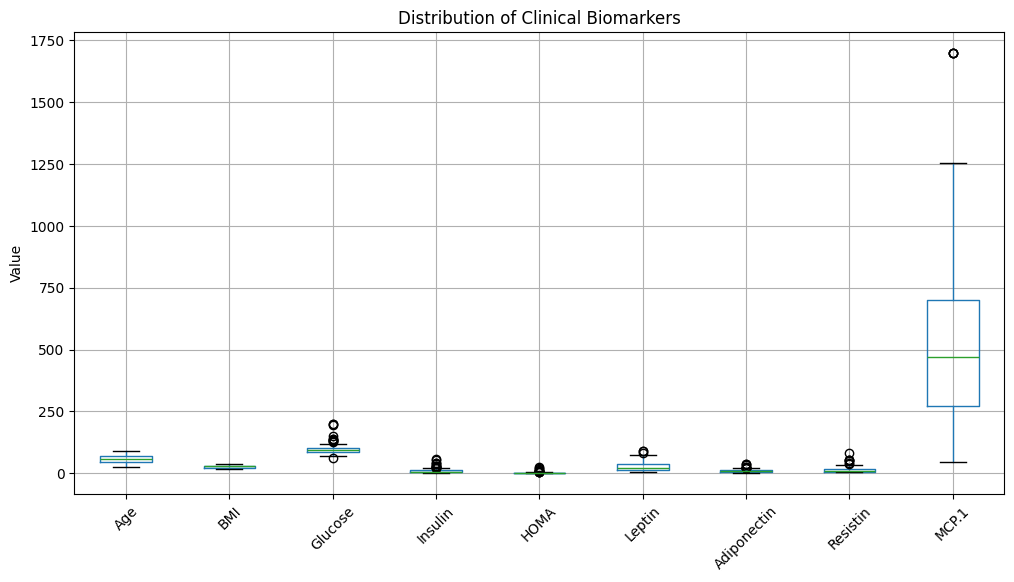

In [5]:
df.drop(columns="Classification").boxplot(figsize=(12, 6), rot=45)

plt.ylabel("Value")
plt.title("Distribution of Clinical Biomarkers")
plt.show()

In [6]:
df.sort_values("MCP.1", ascending=False)[["MCP.1"]].head(10)

,MCP.1
85,1698.440
86,1698.440
88,1698.440
78,1698.440
6,1256.083
24,1227.910
27,1102.110
87,1078.359
84,1041.843
91,994.316


In [7]:
df[df["MCP.1"] == 1698.440]

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
78,86,26.666667,201,41.611,20.630734,47.6470,5.357135,24.37010,1698.44,2
85,65,29.666548,85,14.649,3.071407,26.5166,7.282870,19.46324,1698.44,2
86,48,28.125000,90,2.540,0.563880,15.5325,10.222310,16.11032,1698.44,2
88,48,31.250000,199,12.162,5.969920,18.1314,4.104105,53.63080,1698.44,2


In [8]:
Q1, Q3 = np.percentile(df["MCP.1"], [25, 75]) # Q1 is 25th percentile, Q3 is 75th percentile

IQR = Q3 - Q1 # Calculate the interquartile range

lower = Q1 - 1.5 * IQR # anything below lower is an outlier.
upper = Q3 + 1.5 * IQR # anything above upper is an outlier.

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 269.97825
Q3: 700.085
IQR: 430.10675000000003
Lower limit: -375.1818750000001
Upper limit: 1345.2451250000001


In [9]:
df[(df["MCP.1"] < lower) | (df["MCP.1"] > upper)]

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
78,86,26.666667,201,41.611,20.630734,47.6470,5.357135,24.37010,1698.44,2
85,65,29.666548,85,14.649,3.071407,26.5166,7.282870,19.46324,1698.44,2
86,48,28.125000,90,2.540,0.563880,15.5325,10.222310,16.11032,1698.44,2
88,48,31.250000,199,12.162,5.969920,18.1314,4.104105,53.63080,1698.44,2


# Handling Outliers
## 1. Remove Outliers

In [10]:
df_no_outliers = df[
    (df["MCP.1"] >= lower) &
    (df["MCP.1"] <= upper)
].copy()

print("Original shape:", df.shape)
print("After removing MCP.1 outliers:", df_no_outliers.shape)

Original shape: (116, 10)
After removing MCP.1 outliers: (112, 10)


In [11]:
print("Original MCP.1 mean:", df["MCP.1"].mean())
print("After removal:", df_no_outliers["MCP.1"].mean())

print("Original MCP.1 median:", df["MCP.1"].median())
print("After removal:", df_no_outliers["MCP.1"].median())

Original MCP.1 mean: 534.647
After removal: 493.0829642857143
Original MCP.1 median: 471.3225
After removal: 446.597


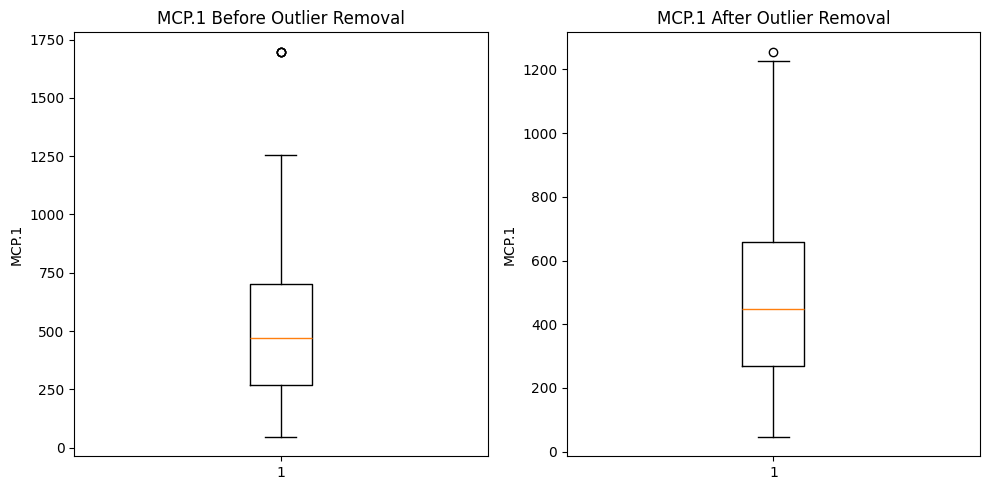

In [12]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df["MCP.1"])
plt.title("MCP.1 Before Outlier Removal")
plt.ylabel("MCP.1")

plt.subplot(1, 2, 2)
plt.boxplot(df_no_outliers["MCP.1"])
plt.title("MCP.1 After Outlier Removal")
plt.ylabel("MCP.1")

plt.tight_layout()
plt.show()

In [13]:
# to check why the new outlier we will use IQR again
Q1_new, Q3_new = np.percentile(df_no_outliers["MCP.1"], [25, 75])
IQR_new = Q3_new - Q1_new

lower_new = Q1_new - 1.5 * IQR_new
upper_new = Q3_new + 1.5 * IQR_new

print("New Q1:", Q1_new)
print("New Q3:", Q3_new)
print("New IQR:", IQR_new)
print("New lower limit:", lower_new)
print("New upper limit:", upper_new)

New Q1: 269.17275
New Q3: 659.27675
New IQR: 390.104
New lower limit: -315.98324999999994
New upper limit: 1244.43275


In [14]:
df_no_outliers[
    (df_no_outliers["MCP.1"] < lower_new) |
    (df_no_outliers["MCP.1"] > upper_new)
][["MCP.1"]]

,MCP.1
6,1256.083


In [15]:
df_no_outliers.loc[6]
# The value is flagged as a potential outlier by the IQR method,
# but it is not strongly isolated from other high MCP.1 values.
# This shows that an IQR outlier is not necessarily an incorrect measurement.

,6
Age,89.000000
BMI,22.700000
Glucose,77.000000
Insulin,4.690000
HOMA,0.890787
Leptin,6.964000
Adiponectin,5.589865
Resistin,12.936100
MCP.1,1256.083000
Classification,1.000000


## 2. Transform Data
MCP.1 contains only positive values and shows a strongly right-skewed distribution, making a logarithmic transformation appropriate for experimentation. The natural logarithm was used to compress large values while retaining all observations.

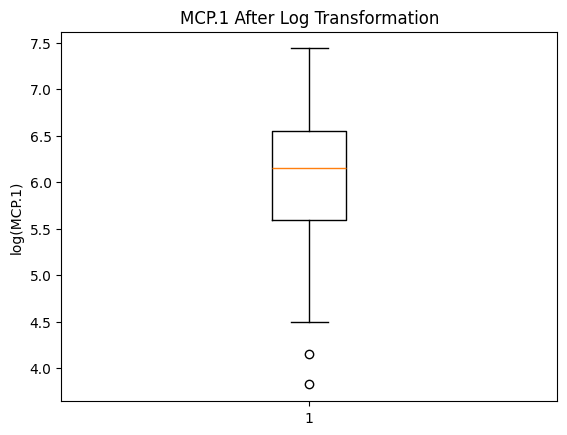

In [16]:
df_log = df.copy()
df_log["MCP.1"] = np.log(df_log["MCP.1"])


plt.boxplot(df_log["MCP.1"])
plt.ylabel("log(MCP.1)")
plt.title("MCP.1 After Log Transformation")
plt.show()

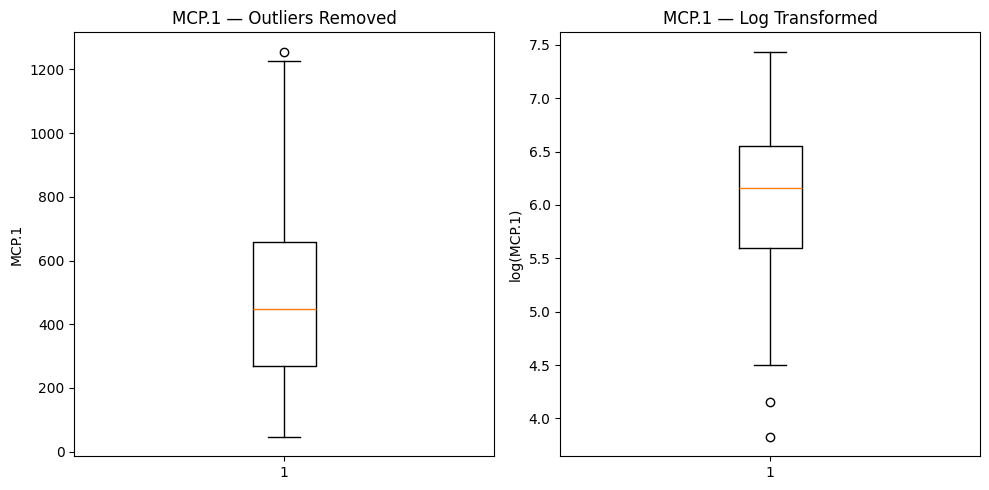

In [17]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df_no_outliers["MCP.1"])
plt.title("MCP.1 — Outliers Removed")
plt.ylabel("MCP.1")

plt.subplot(1, 2, 2)
plt.boxplot(df_log["MCP.1"])
plt.title("MCP.1 — Log Transformed")
plt.ylabel("log(MCP.1)")

plt.tight_layout()
plt.show()

Removal:

“These particular extreme observations are excluded from the dataset.”

Log transformation:

“Keep every observation, but reduce the influence of very large values by changing the scale.”

## 3. Cap or Winsorize
Replace extreme values with thresholds at the lower/upper bounds.

In [18]:
df_capped = df.copy()

In [19]:
df_capped["MCP.1"] = df_capped["MCP.1"].clip(
    lower=lower,
    upper=upper
)

In [20]:
print("Original maximum:", df["MCP.1"].max())
print("Capped maximum:", df_capped["MCP.1"].max())

Original maximum: 1698.44
Capped maximum: 1345.2451250000001


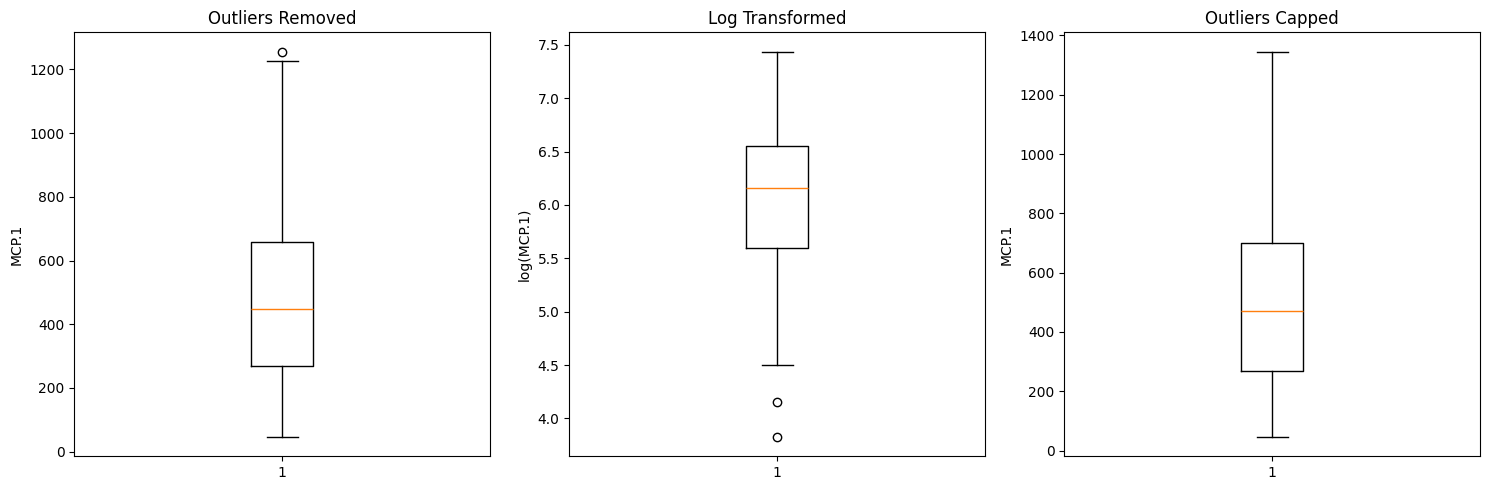

In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.boxplot(df_no_outliers["MCP.1"])
plt.title("Outliers Removed")
plt.ylabel("MCP.1")

plt.subplot(1, 3, 2)
plt.boxplot(df_log["MCP.1"])
plt.title("Log Transformed")
plt.ylabel("log(MCP.1)")

plt.subplot(1, 3, 3)
plt.boxplot(df_capped["MCP.1"])
plt.title("Outliers Capped")
plt.ylabel("MCP.1")

plt.tight_layout()
plt.show()

Left: 4 extreme observations removed → 112 rows
Middle: all 116 observations kept, but MCP.1 log-transformed
Right: all 116 observations kept, but extreme MCP.1 values capped at the IQR limits

Outlier Handling Methods

After identifying extreme values in the MCP.1 biomarker using the IQR method, three different approaches were explored: outlier removal, log transformation, and capping.

1. Outliers Removed

The four observations with MCP.1 = 1698.44 were removed from a copy of the original dataset.

The original dataset contained 116 observations, while the resulting dataset contained 112 observations.

The value 1256.083 remained in the dataset. After removing the four extreme observations, recalculating the IQR produced a new upper limit of 1244.43, causing 1256.083 to be flagged as a new potential outlier. It was retained because there was no clear evidence that the measurement was erroneous.

The IQR limits depend on the distribution of the dataset being analyzed. Therefore, removing observations can change the quartiles and cause previously non-flagged observations to become potential outliers.

Result: Extreme observations are removed, reducing the number of observations.

2. Log Transformation

A log transformation was applied to a separate copy of the original dataset while keeping all 116 observations.

The transformation compresses large values. For example:

1698.44 → 7.44
1256.083 → 7.14

This reduces the influence of very large values without removing the corresponding observations.

After transformation, two low-end values were identified as potential outliers on the log-transformed scale. This demonstrates that changing the scale can also change the distribution and which observations are flagged by the IQR method.

Result: All observations are retained, but the scale and distribution of the data are changed.

3. Outliers Capped

Capping was applied to another copy of the original dataset.

Instead of removing the four 1698.44 observations, values above the original upper IQR limit (1345.245125) were replaced by that boundary value.

Thus:

1698.44 → 1345.245125

All 116 observations remained in the dataset, but the influence of the extreme values was reduced. After capping, no observations fell outside the boxplot whiskers.

Result: All observations are retained, but extreme values are limited to the chosen boundary.

In [22]:
print("Original mean:", df["MCP.1"].mean())
print("Removed mean:", df_no_outliers["MCP.1"].mean())
print("Capped mean:", df_capped["MCP.1"].mean())

print("\nOriginal median:", df["MCP.1"].median())
print("Removed median:", df_no_outliers["MCP.1"].median())
print("Capped median:", df_capped["MCP.1"].median())

print("\nOriginal std:", df["MCP.1"].std())
print("Removed std:", df_no_outliers["MCP.1"].std())
print("Capped std:", df_capped["MCP.1"].std())

Original mean: 534.647
Removed mean: 493.0829642857143
Capped mean: 522.4678663793103

Original median: 471.3225
Removed median: 446.597
Capped median: 471.3225

Original std: 345.9126632559903
Removed std: 270.9550392615755
Capped std: 308.6267604054111


### Statistical Comparison of Outlier Handling Methods

The effect of outlier handling was further examined using the mean, median, and standard deviation of `MCP.1`.

| Statistic          | Original | Outliers Removed | Outliers Capped |
| ------------------ | -------: | ---------------: | --------------: |
| Mean               |   534.65 |           493.08 |          522.47 |
| Median             |   471.32 |           446.60 |          471.32 |
| Standard Deviation |   345.91 |           270.96 |          308.63 |

Observations:

Removing the four extreme observations produced the largest reduction in both the mean and standard deviation.
Capping reduced the mean and standard deviation while retaining all 116 observations.
The median remained unchanged after capping, showing that the extreme values had little effect on the center of the dataset.
Overall, removal had the strongest effect on reducing the influence of extreme values, while capping provided a compromise by retaining the observations and reducing their magnitude.

Key takeaway: Different outlier-handling methods can produce noticeably different statistical results, even when applied to the same original dataset.

In [23]:
print("Log transformed mean:", df_log["MCP.1"].mean())
print("Log transformed median:", df_log["MCP.1"].median())
print("Log transformed std:", df_log["MCP.1"].std())

Log transformed mean: 6.073978894306894
Log transformed median: 6.155528091711906
Log transformed std: 0.6816890928951975


Statistical Summary of Log-Transformed Data

The MCP.1 values were log-transformed using the natural logarithm while retaining all 116 observations.

| Statistic          | Log-Transformed MCP.1 |
| ------------------ | --------------------: |
| Mean               |                 6.074 |
| Median             |                 6.156 |
| Standard Deviation |                 0.682 |


The log transformation substantially compressed the range of the MCP.1 values and reduced the influence of very large measurements. Unlike outlier removal, no observations were deleted.

Key takeaway: Log transformation provides an alternative way of reducing the influence of extreme values while preserving the complete dataset.

## 1. Normalization

* **normalized = (x - minimum) / (maximum - minimum)**

In [24]:
age = df_capped["Age"]

age_normalized = (age - age.min()) / (age.max() - age.min())

print(age_normalized.head())

0    0.369231
1    0.907692
2    0.892308
3    0.676923
4    0.953846
Name: Age, dtype: float64


In [25]:
print("Minimum:", age_normalized.min())
print("Maximum:", age_normalized.max())

Minimum: 0.0
Maximum: 1.0


In [26]:
df_normalized = df_capped.copy()

In [27]:
features = df_normalized.drop(columns="Classification")

df_normalized[features.columns] = (
    features - features.min()
) / (
    features.max() - features.min()
)
df_normalized.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,0.369231,0.253850,0.070922,0.004908,0.000000,0.052299,0.221152,0.060665,0.285724,1
1,0.907692,0.114826,0.226950,0.012190,0.009742,0.052726,0.103707,0.010826,0.325490,1
2,0.892308,0.235278,0.219858,0.036874,0.022058,0.158526,0.571021,0.076906,0.391606,1
3,0.676923,0.148328,0.120567,0.014171,0.005911,0.064811,0.151538,0.121131,0.679064,1
4,0.953846,0.135640,0.226950,0.019936,0.013748,0.027782,0.086940,0.093375,0.560317,1


In [28]:
print(df_normalized.drop(columns="Classification").min())
print(df_normalized.drop(columns="Classification").max())

Age            0.0
BMI            0.0
Glucose        0.0
Insulin        0.0
HOMA           0.0
Leptin         0.0
Adiponectin    0.0
Resistin       0.0
MCP.1          0.0
dtype: float64
Age            1.0
BMI            1.0
Glucose        1.0
Insulin        1.0
HOMA           1.0
Leptin         1.0
Adiponectin    1.0
Resistin       1.0
MCP.1          1.0
dtype: float64


**Why Normalize Data?**

Clinical datasets often contain features with very different numerical ranges. For example, Age may range from tens of years, while MCP.1 can have values in the thousands.

When features have very different scales, some machine learning algorithms may give greater influence to features with larger numerical values. Normalization puts the features on a common scale, making them easier for these algorithms to work with.

In this project, Min-Max normalization was used to rescale each feature to a range between 0 and 1.

**Benefits for Machine Learning**

Normalization can be useful because it:

* Puts features on a comparable scale, preventing large-valued features from dominating calculations.
* Improves optimization for algorithms that use gradient-based methods, since similarly scaled features can help the model converge more efficiently.
* Helps distance-based algorithms such as K-Nearest Neighbors and K-Means, where differences in feature scales directly affect distance calculations.
* Makes numerical data easier to work with when several features have very different units or ranges.

`Note: Normalization is not necessary for every machine learning algorithm. Tree-based methods such as Decision Trees and Random Forests are generally much less affected by feature scaling.`

When these techniques are used in an actual machine learning pipeline, the scaling parameters should be calculated using the training data only and then applied to the validation or test data. This prevents information from the test set from influencing the preprocessing step.

## 2. Standardization
What is Standardization?

Normalization put every feature between 0 and 1.

Standardization does something different: it transforms a feature so that its values are centered around 0, with a standard deviation of 1.

The formula is:

$$ z = \frac{x-\mu}{\sigma} $$

where:

* x = original value
* μ = mean
* σ = standard deviation of the feature
* z = standardized value

This means:

* A value above the mean gets a positive standardized value.
* A value below the mean gets a negative standardized value.
* A value equal to the mean becomes 0.

In [29]:
age = df_capped["Age"]

age_standardized = (age - age.mean()) / age.std()

print(age_standardized.head())

0   -0.577289
1    1.594902
2    1.532839
3    0.663963
4    1.781089
Name: Age, dtype: float64


In [30]:
print("Mean:", round(age_standardized.mean(),2))
print("Standard deviation:", round(age_standardized.std(),2))

Mean: 0.0
Standard deviation: 1.0


In [31]:
df_standardized = df_capped.copy()

features = df_standardized.drop(columns="Classification")

df_standardized[features.columns] = (
    features - features.mean()
) / features.std()

In [32]:
df_standardized.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,-0.577289,-0.813147,-1.233869,-0.725591,-0.611629,-0.928307,-0.069918,-0.543161,-0.341363,1
1,1.594902,-1.372795,-0.257184,-0.685066,-0.545872,-0.926394,-0.694338,-0.860481,-0.173938,1
2,1.532839,-0.887912,-0.301578,-0.547697,-0.462745,-0.452257,1.790232,-0.439752,0.104428,1
3,0.663963,-1.237933,-0.923106,-0.674041,-0.571729,-0.872237,-0.440036,-0.158181,1.314702,1
4,1.781089,-1.289009,-0.257184,-0.641958,-0.518830,-1.038178,-0.783482,-0.334899,0.814745,1


In [33]:
print(df_standardized.drop(columns="Classification").mean().round(2))
print(df_standardized.drop(columns="Classification").std().round(2))

Age            0.0
BMI           -0.0
Glucose        0.0
Insulin        0.0
HOMA           0.0
Leptin         0.0
Adiponectin    0.0
Resistin       0.0
MCP.1          0.0
dtype: float64
Age            1.0
BMI            1.0
Glucose        1.0
Insulin        1.0
HOMA           1.0
Leptin         1.0
Adiponectin    1.0
Resistin       1.0
MCP.1          1.0
dtype: float64


**Standardization Results**

Standardization was applied to the nine clinical measurement features while leaving Classification unchanged. Each feature was transformed so that its mean was approximately 0 and its standard deviation was 1.

The resulting standardized values indicate how far each observation lies from the feature's mean in terms of standard deviations. Positive values represent observations above the mean, while negative values represent observations below the mean.

The verification confirmed that all standardized features have a mean approximately equal to 0 and a standard deviation equal to 1.

So now we've completed both major scaling techniques:

Normalization: values scaled to 0–1

Standardization: values centered around 0 with standard deviation 1

| Situation                                                 | Often useful                               |
| --------------------------------------------------------- | ------------------------------------------ |
| Need values specifically between 0 and 1                  | **Normalization**                          |
| Features roughly need comparable scale, centered around 0 | **Standardization**                        |
| KNN / K-Means / distance-based methods                    | Either, depending on data                  |
| Logistic/linear models, SVM, PCA                          | **Standardization is often a good choice** |
| Neural networks with inputs naturally bounded 0–1         | **Normalization can be useful**            |
| Decision trees / Random Forests                           | Scaling usually isn't important            |


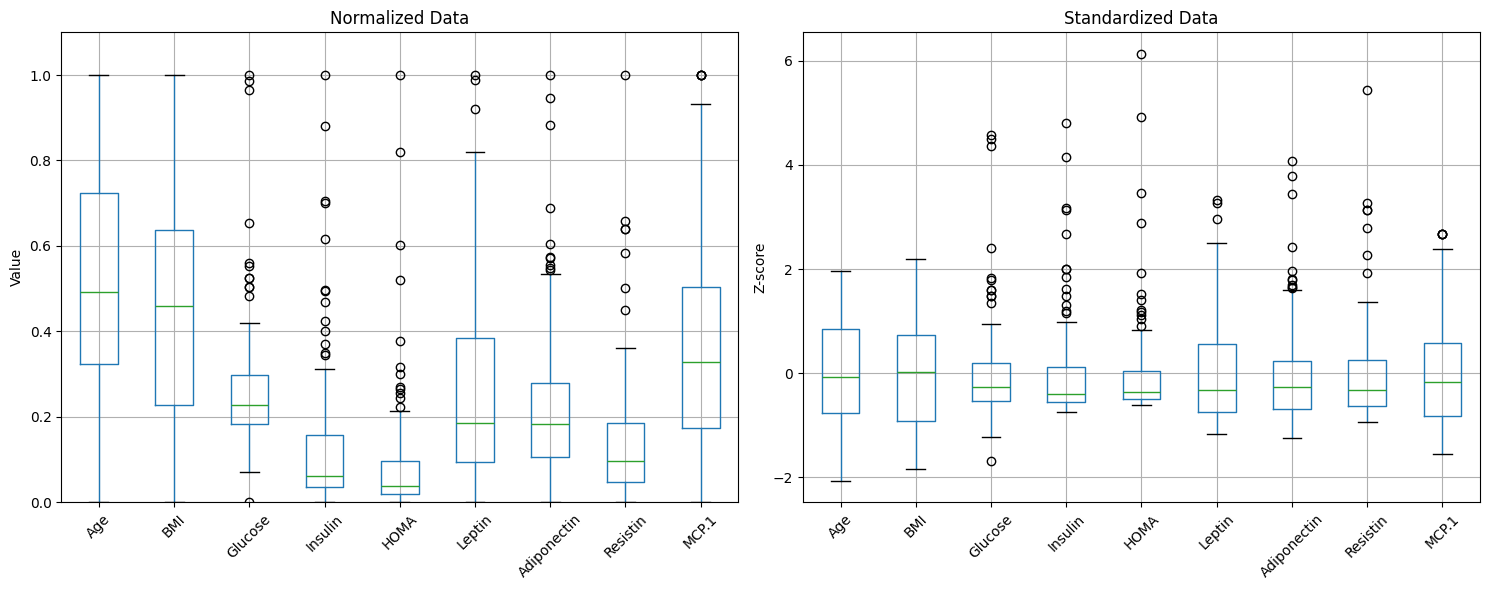

In [34]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
df_normalized.drop(columns="Classification").boxplot(rot=45)
plt.title("Normalized Data")
plt.ylabel("Value")
plt.ylim(0, 1.1)

plt.subplot(1, 2, 2)
df_standardized.drop(columns="Classification").boxplot(rot=45)
plt.title("Standardized Data")
plt.ylabel("Z-score")

plt.tight_layout()
plt.show()

**Comparison of Normalization and Standardization**

The normalized and standardized datasets were visualized using boxplots to compare the effect of the two scaling techniques.

The normalized data places every feature between 0 and 1, while the standardized data expresses values as z-scores, centered around 0 with a standard deviation of 1.

The boxplots show that the underlying distributions of the features remain essentially unchanged after scaling. Features such as Glucose, Insulin, HOMA, Leptin, Adiponectin, Resistin, and MCP.1 continue to show skewed distributions and extreme observations.

For the normalized data, these extreme values appear near the upper end of the 0–1 range. In the standardized data, the same observations may appear as large positive or negative z-scores, indicating that they are several standard deviations away from the mean.

Key takeaway: Normalization and standardization change the scale of the data, not its underlying distribution. The choice between them depends on the requirements of the machine learning algorithm and the characteristics of the dataset.

## Conclusion

This project focused on analyzing and preprocessing clinical biomarker data using Python, with an emphasis on understanding how data quality and feature scaling affect machine learning preparation.

The dataset was first explored using Pandas and visualized using Matplotlib to understand the distributions of the clinical measurements. The MCP.1 feature was investigated in detail because it contained several extreme values. The IQR method was used to identify potential outliers, and three different approaches to handling them were explored: removal, log transformation, and capping.

The results showed that each method affects the data differently. Removing outliers reduces the number of observations and can substantially reduce the influence of extreme values. Log transformation retains all observations while compressing large values and reducing their influence. Capping also retains all observations while limiting extreme values to a chosen boundary.

The project then explored two common feature-scaling techniques: Min-Max normalization and standardization. Normalization rescaled the features to a range of 0 to 1, while standardization transformed them to have a mean approximately equal to 0 and a standard deviation of 1. Visualization showed that these scaling methods change the scale of the data but do not fundamentally change its underlying distribution.

Overall, this project provided practical experience with data inspection, visualization, outlier analysis, outlier handling, normalization, and standardization, building a foundation for preparing biological and clinical datasets for machine learning.

**Key Takeaways**
* Outliers are not necessarily errors and should be investigated before being removed.
* Different outlier-handling methods can produce different results.
* Normalization and standardization solve similar scaling problems but work differently.
* Feature scaling does not automatically remove skewness or outliers.
* The appropriate preprocessing method depends on the dataset and the machine learning algorithm being used.